# Week 3 — Mixture Models, EM, Clustering and PCA

**Syllabus topics:** Measuring dissimilarity · K-means clustering · mixtures of Gaussians and an alternative view of EM · hierarchical clustering · evaluating the output of clustering · PCA · choosing the number of latent dimensions · factor analysis.

Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Theory — Clustering: measuring dissimilarity

Clustering needs a notion of "how different are two days?". The same four days look different under Euclidean, Manhattan and cosine dissimilarity.

      date  temp_max  temp_min  wind  precipitation
2012-01-01      12.8       5.0   4.7            0.0
2012-01-02      10.6       2.8   4.5           10.9
2012-06-29      21.7      15.0   1.9            0.3
2012-07-19      25.0      14.4   2.2            0.0
2012-12-26       6.7       3.3   4.9            4.6 

euclidean dissimilarity:
             01 Jan 2012  02 Jan 2012  29 Jun 2012  19 Jul 2012  26 Dec 2012
01 Jan 2012         0.00         1.72         3.04         3.05         1.14
02 Jan 2012         1.72         0.00         3.74         3.79         1.12
29 Jun 2012         3.04         3.74         0.00         0.51         3.79
19 Jul 2012         3.05         3.79         0.51         0.00         3.88
26 Dec 2012         1.14         1.12         3.79         3.88         0.00 

cityblock dissimilarity:
             01 Jan 2012  02 Jan 2012  29 Jun 2012  19 Jul 2012  26 Dec 2012
01 Jan 2012         0.00         2.51         5.19         5.27         2.00
02 Jan 2012       

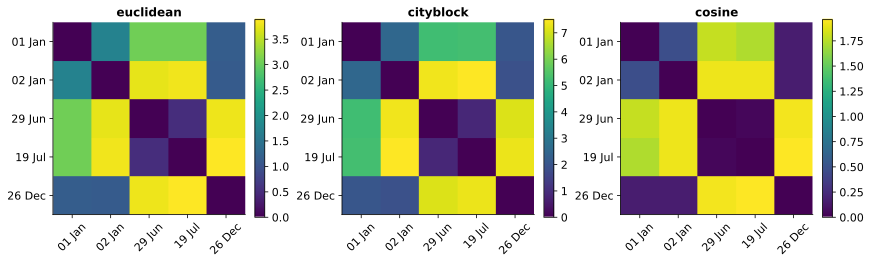

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from weather import load

d = load()
X = d[["temp_max", "temp_min", "wind", "precipitation"]]
Z = ((X - X.mean()) / X.std()).values                  # put the four numbers on the same scale first
days = [0, 1, 180, 200, 360]                           # five days: two January days, two summer days, one late-December day
names = d.date.dt.strftime("%d %b %Y").values[days]
print(d.loc[days, ["date", "temp_max", "temp_min", "wind", "precipitation"]].to_string(index=False), "\n")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
for a, metric in zip(ax, ["euclidean", "cityblock", "cosine"]):
    D = cdist(Z[days], Z[days], metric)
    print(f"{metric} dissimilarity:"); print(pd.DataFrame(D, index=names, columns=names).round(2), "\n")
    im = a.imshow(D, cmap="viridis"); a.grid(False); a.set_title(metric)
    a.set_xticks(range(5), [n[:6] for n in names], rotation=45); a.set_yticks(range(5), [n[:6] for n in names])
    fig.colorbar(im, ax=a, shrink=.8)
plt.show()

## Practice 1 — Implement K-means clustering to categorize data

Repeat two steps until nothing changes: give each day to the nearest centre, then move each centre to the mean of its days. The elbow and the silhouette help choose how many clusters k to ask for.

k   total squared distance   silhouette
2                   3604        0.351
3                   2497        0.380
4                   2110        0.372
5                   1858        0.280
6                   1627        0.280
7                   1491        0.284
8                   1368        0.256

agreement of our k = 4 with scikit-learn's KMeans (1 = identical): 0.996
         days  temp_max  wind  rain_share
cluster                                  
0         378     10.47  2.21        0.34
1         197     11.23  5.29        0.56
2         597     23.65  2.81        0.16
3         289     12.92  4.07        1.00


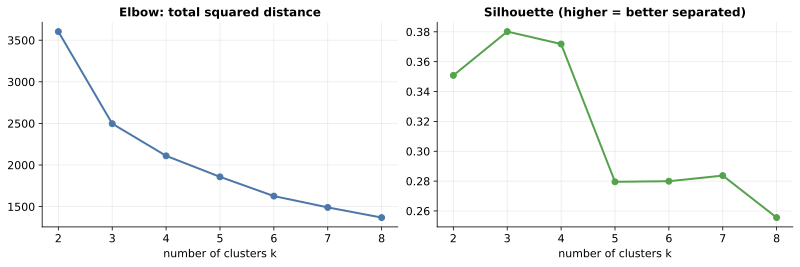

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

def kmeans(Z, k, seed, steps=100):
    centres = Z[np.random.default_rng(seed).choice(len(Z), k, replace=False)]
    for _ in range(steps):
        dist = ((Z[:, None] - centres[None]) ** 2).sum(-1)
        labels = dist.argmin(1)                                          # step 1: nearest centre
        new = np.array([Z[labels == j].mean(0) for j in range(k)])       # step 2: move each centre to the mean of its days
        if np.allclose(new, centres): break
        centres = new
    return labels, dist.min(1).sum()

best = {k: min((kmeans(Z, k, seed) for seed in range(8)), key=lambda r: r[1]) for k in range(2, 9)}   # best of 8 starts for each k
inertia = [best[k][1] for k in range(2, 9)]
silhouette = [silhouette_score(Z, best[k][0]) for k in range(2, 9)]
print("k   total squared distance   silhouette")
for k, i, s in zip(range(2, 9), inertia, silhouette): print(f"{k}   {i:>20.0f}   {s:>10.3f}")

labels = best[4][0]
print("\nagreement of our k = 4 with scikit-learn's KMeans (1 = identical):", round(adjusted_rand_score(labels, KMeans(4, n_init=10, random_state=0).fit_predict(Z)), 3))
print(d.assign(cluster=labels).groupby("cluster").agg(days=("rain", "size"), temp_max=("temp_max", "mean"), wind=("wind", "mean"), rain_share=("rain", "mean")).round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(range(2, 9), inertia, "o-"); ax[0].set_title("Elbow: total squared distance"); ax[0].set_xlabel("number of clusters k")
ax[1].plot(range(2, 9), silhouette, "o-", color="#54a24b"); ax[1].set_title("Silhouette (higher = better separated)"); ax[1].set_xlabel("number of clusters k")
plt.show()

## Practice 1 — Implement mixtures of Gaussians (EM) to categorize data: an alternative view of EM

K-means gives each day to one cluster; a Gaussian mixture says "70% cluster A, 30% cluster B". EM alternates an E-step (membership probabilities) and an M-step (re-fit each cluster). Every EM step can only raise the likelihood.

log-likelihood never decreases: True | first -8112 -> last -2398
mixing weights: [0.28, 0.02, 0.12, 0.57] | days that are clearly in one cluster (> 90%): 92%


BIC for 1..8 components: {1: 13918, 2: 3103, 3: 3040, 4: 3073, 5: 2883, 6: 2938, 7: 2529, 8: 2327} | lowest: 8 (it keeps falling: no sharp number of clusters)


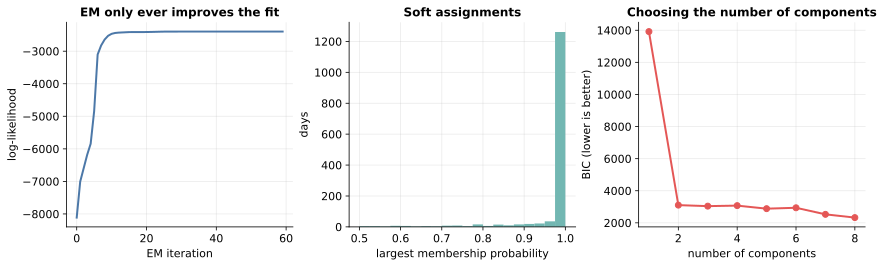

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values
n, dim, k = *Z.shape, 4

rng = np.random.default_rng(0)
mu, var, pi = Z[rng.choice(n, k, replace=False)], np.ones((k, dim)), np.full(k, 1 / k)     # diagonal covariances keep it short
log_lik = []
for step in range(60):
    logp = -0.5 * (((Z[:, None] - mu) ** 2 / var).sum(-1) + np.log(var).sum(-1) + dim * np.log(2 * np.pi)) + np.log(pi)
    top = logp.max(1, keepdims=True)
    log_lik.append(float((top[:, 0] + np.log(np.exp(logp - top).sum(1))).sum()))
    r = np.exp(logp - top); r /= r.sum(1, keepdims=True)                 # E-step: membership probabilities
    nk = r.sum(0)                                                        # M-step: weighted means, variances and sizes
    mu, var, pi = (r.T @ Z) / nk[:, None], (r.T @ Z ** 2) / nk[:, None] - ((r.T @ Z) / nk[:, None]) ** 2 + 1e-6, nk / n

print("log-likelihood never decreases:", all(b >= a - 1e-9 for a, b in zip(log_lik, log_lik[1:])), f"| first {log_lik[0]:.0f} -> last {log_lik[-1]:.0f}")
print("mixing weights:", pi.round(2).tolist(), "| days that are clearly in one cluster (> 90%):", f"{(r.max(1) > .9).mean():.0%}")
bic = {m: GaussianMixture(m, n_init=3, random_state=0).fit(Z).bic(Z) for m in range(1, 9)}
print("BIC for 1..8 components:", {m: round(v) for m, v in bic.items()}, "| lowest:", min(bic, key=bic.get), "(it keeps falling: no sharp number of clusters)")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].plot(log_lik); ax[0].set_xlabel("EM iteration"); ax[0].set_ylabel("log-likelihood"); ax[0].set_title("EM only ever improves the fit")
ax[1].hist(r.max(1), bins=20, color="#72b7b2"); ax[1].set_xlabel("largest membership probability"); ax[1].set_ylabel("days"); ax[1].set_title("Soft assignments")
ax[2].plot(list(bic), list(bic.values()), "o-", color="#e45756"); ax[2].set_xlabel("number of components"); ax[2].set_ylabel("BIC (lower is better)"); ax[2].set_title("Choosing the number of components")
plt.show()

## Practice 1 — Implement hierarchical clustering to categorize data (and evaluate the clusterings)

Start with every day on its own and repeatedly merge the two closest groups (Ward's rule). Cutting the tree gives clusters. We then compare the clusterings with each other and with the dataset's own weather label, which no algorithm ever saw.

silhouette of each method (higher = better separated): {'hierarchical': 0.27, 'k-means': 0.372, 'Gaussian mixture': 0.032}

How much do the methods agree? (adjusted Rand index, 1 = identical):
                  hierarchical  k-means  Gaussian mixture
hierarchical              1.00     0.51              0.30
k-means                   0.51     1.00              0.29
Gaussian mixture          0.30     0.29              1.00

Hierarchical clusters against the labelled weather (never used for clustering):
weather  drizzle  fog  rain  snow  sun
cluster                               
0             19   27    61     0  308
1             30   62   124     2  253
2              4   12    95    11   79
3              0    0   361    13    0


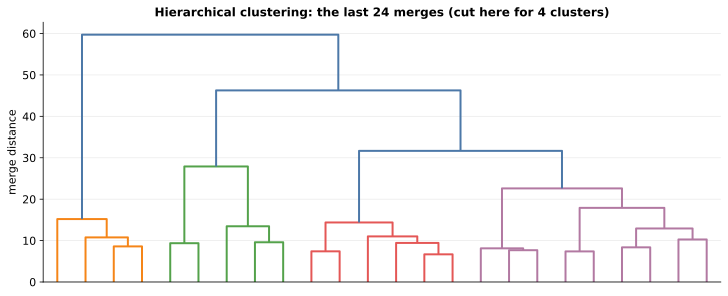

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

tree = linkage(Z, method="ward")
found = {
    "hierarchical": fcluster(tree, 4, criterion="maxclust") - 1,
    "k-means": KMeans(4, n_init=10, random_state=0).fit_predict(Z),
    "Gaussian mixture": GaussianMixture(4, n_init=3, random_state=0).fit_predict(Z),
}
print("silhouette of each method (higher = better separated):", {m: round(silhouette_score(Z, l), 3) for m, l in found.items()})
print("\nHow much do the methods agree? (adjusted Rand index, 1 = identical):")
names = list(found)
print(pd.DataFrame([[adjusted_rand_score(found[a], found[b]) for b in names] for a in names], index=names, columns=names).round(2))
print("\nHierarchical clusters against the labelled weather (never used for clustering):")
print(pd.crosstab(found["hierarchical"], d.weather).rename_axis("cluster"))

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(tree, truncate_mode="lastp", p=24, no_labels=True, color_threshold=tree[-3, 2], ax=ax)
ax.set_title("Hierarchical clustering: the last 24 merges (cut here for 4 clusters)"); ax.set_ylabel("merge distance"); plt.show()

## Practice 2 — Create a program to perform PCA

Principal component analysis finds the directions along which the days vary most. We get them from the eigenvectors of the covariance matrix and compare with scikit-learn.

variance explained by each component: [0.52, 0.3, 0.155, 0.024]
same as scikit-learn: True 

loadings (how each component mixes the original columns):
           PC1   PC2
temp_max  0.65  0.24
temp_min  0.60  0.41
wind     -0.27  0.68
log_rain -0.38  0.56

PC1: warm, dry and calm (high) versus cool and wet (low). PC2: mostly wind and rain amount.


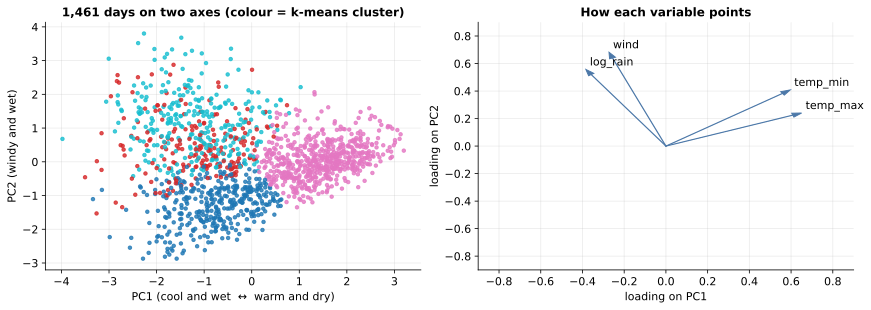

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

values, vectors = np.linalg.eigh(np.cov(Z, rowvar=False))        # eigen-decomposition of the covariance matrix
order = values.argsort()[::-1]; values, vectors = values[order], vectors[:, order]
vectors = vectors * np.sign(vectors[0])                         # an eigenvector can point either way; make temp_max positive
scores = Z @ vectors                                               # the days expressed on the new axes
sk = PCA().fit(Z)
print("variance explained by each component:", (values / values.sum()).round(3).tolist())
print("same as scikit-learn:", np.allclose(values / values.sum(), sk.explained_variance_ratio_), "\n")
print("loadings (how each component mixes the original columns):")
print(pd.DataFrame(vectors[:, :2], index=X.columns, columns=["PC1", "PC2"]).round(2))
print("\nPC1: warm, dry and calm (high) versus cool and wet (low). PC2: mostly wind and rain amount.")

groups = KMeans(4, n_init=10, random_state=0).fit_predict(Z)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = ax[0].scatter(scores[:, 0], scores[:, 1], c=groups, cmap="tab10", s=12, alpha=.8)
ax[0].set_xlabel("PC1 (cool and wet  ↔  warm and dry)"); ax[0].set_ylabel("PC2 (windy and wet)"); ax[0].set_title("1,461 days on two axes (colour = k-means cluster)")
for j, name in enumerate(X.columns):
    ax[1].arrow(0, 0, vectors[j, 0], vectors[j, 1], head_width=.03, color="#4c78a8", length_includes_head=True)
    ax[1].annotate(name, (vectors[j, 0], vectors[j, 1]), xytext=(4, 4), textcoords="offset points")
ax[1].set_xlim(-.9, .9); ax[1].set_ylim(-.9, .9); ax[1].set_xlabel("loading on PC1"); ax[1].set_ylabel("loading on PC2"); ax[1].set_title("How each variable points")
plt.show()

## Theory — Choosing the number of latent dimensions

How many principal components are enough? Three guides: the share of variance kept, the error when the data are rebuilt from fewer components, and the likelihood on days the model did not see (cross-validation).

components  variance kept  rebuild error  held-out log-likelihood
         1           52%          0.480                    -5.41
         2           82%          0.180                    -5.15
         3           98%          0.024                    -4.77
         4          100%          0.000                    -4.77

best number of components by cross-validation: 3


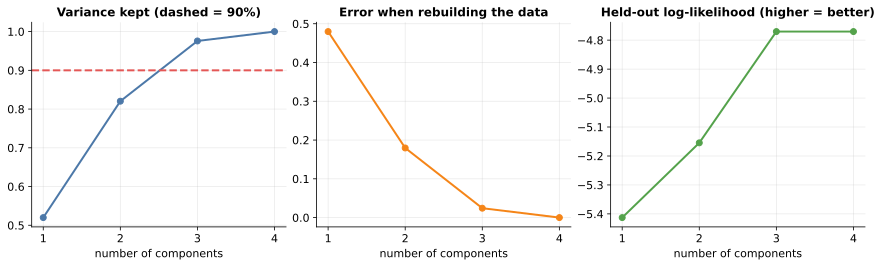

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

ks = [1, 2, 3, 4]
kept = np.cumsum(PCA().fit(Z).explained_variance_ratio_)
error = [np.mean((Z - PCA(k).fit(Z).inverse_transform(PCA(k).fit(Z).transform(Z))) ** 2) for k in ks]
cv = [cross_val_score(PCA(k), Z, cv=5).mean() for k in ks]         # held-out log-likelihood of a probabilistic PCA model
print("components  variance kept  rebuild error  held-out log-likelihood")
for k, a, e, c in zip(ks, kept, error, cv): print(f"{k:>10}  {a:>12.0%}  {e:>13.3f}  {c:>23.2f}")
print("\nbest number of components by cross-validation:", ks[int(np.argmax(cv))])

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].plot(ks, kept, "o-"); ax[0].axhline(.9, ls="--", color="#e45756"); ax[0].set_title("Variance kept (dashed = 90%)")
ax[1].plot(ks, error, "o-", color="#f58518"); ax[1].set_title("Error when rebuilding the data")
ax[2].plot(ks, cv, "o-", color="#54a24b"); ax[2].set_title("Held-out log-likelihood (higher = better)")
for a in ax: a.set_xlabel("number of components"); a.set_xticks(ks)
plt.show()

## Theory — Factor analysis

Factor analysis assumes a few hidden factors plus separate noise for each variable. PCA only rotates the data; factor analysis models the noise, so it can say how much of each variable is explained by the shared factors.

factor analysis loadings:
          factor 1  factor 2
temp_max     -0.95     -0.05
temp_min     -0.93      0.20
wind          0.16      0.39
log_rain      0.33      0.82

noise variance of each variable (what the two factors do NOT explain):
temp_max    0.09
temp_min    0.10
wind        0.83
log_rain    0.22

PCA loadings for comparison:
           PC1   PC2
temp_max  0.65  0.24
temp_min  0.60  0.41
wind     -0.27  0.68
log_rain -0.38  0.56


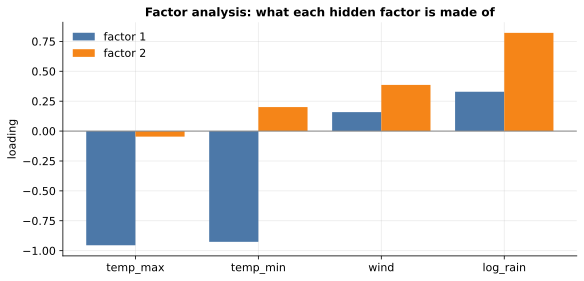

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis, PCA
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

fa = FactorAnalysis(2, random_state=0).fit(Z)
pca = PCA(2).fit(Z)
loadings = pd.DataFrame(fa.components_.T, index=X.columns, columns=["factor 1", "factor 2"])
print("factor analysis loadings:"); print(loadings.round(2))
print("\nnoise variance of each variable (what the two factors do NOT explain):")
print(pd.Series(fa.noise_variance_, index=X.columns).round(2).to_string())
print("\nPCA loadings for comparison:"); print(pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"]).round(2))

pos = np.arange(4)
plt.figure(figsize=(8, 3.8))
plt.bar(pos - .2, loadings["factor 1"], .4, label="factor 1"); plt.bar(pos + .2, loadings["factor 2"], .4, label="factor 2")
plt.xticks(pos, X.columns); plt.axhline(0, color="#888", lw=1); plt.ylabel("loading"); plt.title("Factor analysis: what each hidden factor is made of"); plt.legend(); plt.show()